# Portfolio Project: Automobile Price Analysis and Regression Modeling 

---

# 03 — Exploratory Data Analysis
## Automobile Pricing Analytics

### Analytical purpose
This notebook investigates how automobile characteristics are associated with vehicle price and identifies the relationships that should be carried forward into regression modeling.

It builds on **Notebook 02 — Data Cleaning & Feature Engineering**, using the cleaned `auto_cleaned.csv` dataset.

### Research questions
1. **How is automobile price distributed in this sample?**
2. **Which continuous vehicle characteristics are most strongly associated with price?**
3. **How does price vary across important categorical characteristics?**
4. **Which predictor relationships warrant further investigation in regression models?**
5. **Are the strongest candidate predictors also strongly related to one another?**

### Interpretation boundary
This notebook is exploratory. Correlation and group differences describe associations in the observed sample; they do **not** establish causal effects.


## 1. Setup and load the analysis-ready data

Notebook 03 reads the cleaned dataset produced by Notebook 02 rather than repeating the cleaning process. This keeps each stage of the project conceptually distinct and reproducible.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

candidate_paths = [
    Path("../data/auto_cleaned.csv"),
    Path("data/auto_cleaned.csv"),
    Path("auto_cleaned.csv"),
]

data_path = next((path for path in candidate_paths if path.exists()), None)

if data_path is None:
    raise FileNotFoundError(
        "auto_cleaned.csv was not found. Run Notebook 02 first or place the file "
        "in ../data/, data/, or the current directory."
    )

df = pd.read_csv(data_path)

print(f"Dataset location: {data_path.resolve()}")
print(f"Shape: {df.shape}")

Dataset location: /mnt/data/auto_cleaned.csv
Shape: (201, 29)


In [2]:
expected_columns = {
    "price", "engine-size", "horsepower", "curb-weight",
    "city-mpg", "highway-mpg", "wheel-base", "length",
    "width", "bore", "drive-wheels", "body-style"
}

missing_expected = expected_columns.difference(df.columns)
assert not missing_expected, f"Expected columns missing: {sorted(missing_expected)}"
assert df["price"].notna().all(), "Price contains missing values."
assert (df["price"] > 0).all(), "Price should be positive."

df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,height,curb-weight,engine-type,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,highway-L/100km,horsepower-binned
0,3,122.000,alfa-romero,gas,std,two,convertible,rwd,front,88.600,168.800,64.100,48.800,2548,dohc,four,130,mpfi,3.470,2.680,9.000,111.000,"5,000.000",21,27,"13,495.000",11.190,8.704,Low
1,3,122.000,alfa-romero,gas,std,two,convertible,rwd,front,88.600,168.800,64.100,48.800,2548,dohc,four,130,mpfi,3.470,2.680,9.000,111.000,"5,000.000",21,27,"16,500.000",11.190,8.704,Low
2,1,122.000,alfa-romero,gas,std,two,hatchback,rwd,front,94.500,171.200,65.500,52.400,2823,ohcv,six,152,mpfi,2.680,3.470,9.000,154.000,"5,000.000",19,26,"16,500.000",12.368,9.038,Medium
3,2,164.000,audi,gas,std,four,sedan,fwd,front,99.800,176.600,66.200,54.300,2337,ohc,four,109,mpfi,3.190,3.400,10.000,102.000,"5,500.000",24,30,"13,950.000",9.792,7.833,Low
4,2,164.000,audi,gas,std,four,sedan,4wd,front,99.400,176.600,66.400,54.300,2824,ohc,five,136,mpfi,3.190,3.400,8.000,115.000,"5,500.000",18,22,"17,450.000",13.056,10.682,Low


## 2. Question 1 — How is automobile price distributed?

Before studying predictors, the target variable itself should be understood. Price dispersion matters because a wide or skewed distribution can make average error measures sensitive to expensive vehicles and can affect how regression residuals behave later.

In [3]:
price_summary = df["price"].describe().to_frame("price")
price_summary

,price
count,201.000
mean,"13,207.129"
std,"7,947.066"
min,"5,118.000"
25%,"7,775.000"
50%,"10,295.000"
75%,"16,500.000"
max,"45,400.000"


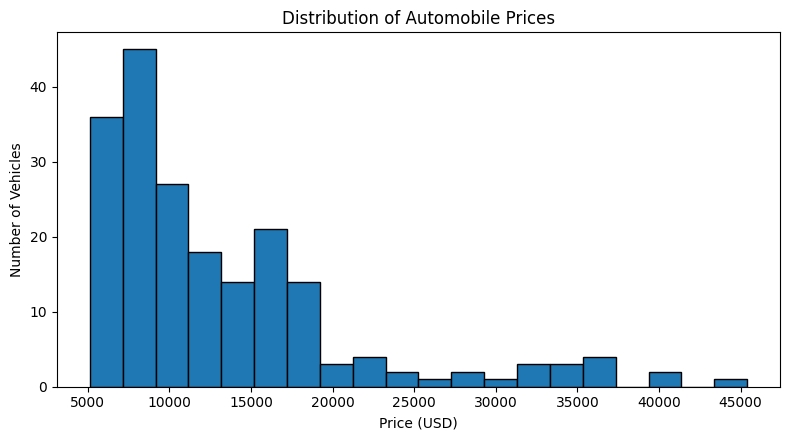

In [4]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(df["price"], bins=20, edgecolor="black")
ax.set_title("Distribution of Automobile Prices")
ax.set_xlabel("Price (USD)")
ax.set_ylabel("Number of Vehicles")
plt.tight_layout()
plt.show()

In [5]:
price_skew = df["price"].skew()
price_median = df["price"].median()
price_mean = df["price"].mean()

print(f"Mean price:   ${price_mean:,.0f}")
print(f"Median price: ${price_median:,.0f}")
print(f"Skewness:      {price_skew:.3f}")

Mean price:   $13,207
Median price: $10,295
Skewness:      1.810


### Interpretation

The price distribution is right-skewed: a relatively small set of expensive automobiles extends the upper tail. Consequently, the mean price is higher than the median price.

This matters for later regression work because large-price observations can exert substantial influence on squared-error measures. Notebook 04 should therefore inspect fitted relationships and residual behavior rather than relying on a single goodness-of-fit statistic.


## 3. Question 2 — Which continuous characteristics are most strongly associated with price?

The original project examined several numerical variables individually. The same variables are retained here, but evaluated in a consistent summary table using:

- **Pearson correlation coefficient (`r`)** to describe the direction and strength of linear association;
- **p-value** for the null hypothesis of zero population correlation.

Statistical significance is not the same as practical importance, and correlation does not imply causation.


In [6]:
candidate_numeric = [
    "wheel-base",
    "length",
    "width",
    "curb-weight",
    "engine-size",
    "bore",
    "stroke",
    "compression-ratio",
    "horsepower",
    "peak-rpm",
    "city-mpg",
    "highway-mpg",
]

correlation_rows = []

for feature in candidate_numeric:
    r, p = stats.pearsonr(df[feature], df["price"])
    correlation_rows.append(
        {
            "feature": feature,
            "pearson_r": r,
            "abs_r": abs(r),
            "p_value": p,
        }
    )

price_correlations = (
    pd.DataFrame(correlation_rows)
      .sort_values("abs_r", ascending=False)
      .reset_index(drop=True)
)

price_correlations

,feature,pearson_r,abs_r,p_value
0,engine-size,0.872,0.872,0.000
1,curb-weight,0.834,0.834,0.000
2,horsepower,0.810,0.810,0.000
3,width,0.751,0.751,0.000
4,highway-mpg,-0.705,0.705,0.000
5,length,0.691,0.691,0.000
6,city-mpg,-0.687,0.687,0.000
7,wheel-base,0.585,0.585,0.000
8,bore,0.543,0.543,0.000
9,peak-rpm,-0.102,0.102,0.151


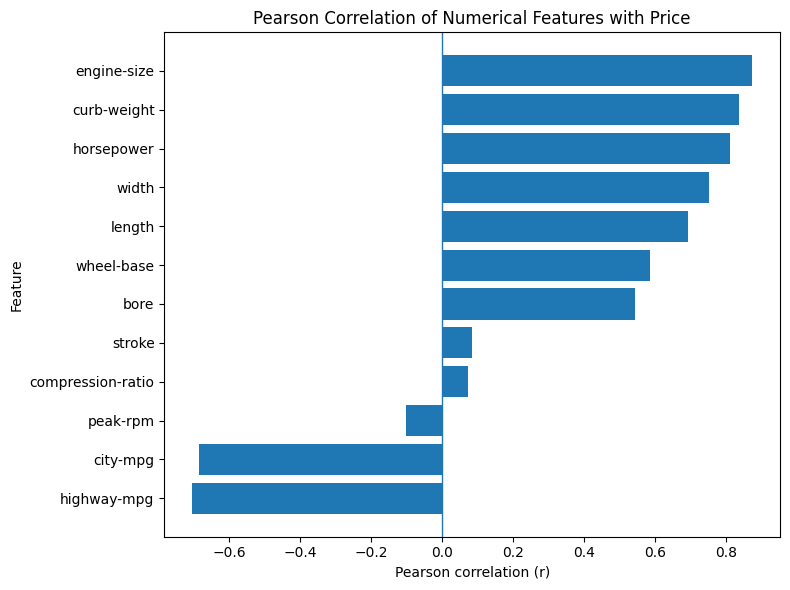

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))

plot_data = price_correlations.sort_values("pearson_r")
ax.barh(plot_data["feature"], plot_data["pearson_r"])
ax.axvline(0, linewidth=1)
ax.set_title("Pearson Correlation of Numerical Features with Price")
ax.set_xlabel("Pearson correlation (r)")
ax.set_ylabel("Feature")

plt.tight_layout()
plt.show()

### Main numerical relationships

The strongest positive linear associations with price are expected among variables that describe vehicle size, engine capacity, and power—particularly `engine-size`, `curb-weight`, `horsepower`, and `width`.

Fuel-economy variables (`city-mpg` and `highway-mpg`) show negative relationships with price in this sample: vehicles with lower MPG tend to be more expensive. This is an association within this historical dataset, not evidence that lower fuel economy itself causes a higher price.

Variables with weak linear correlation should not automatically be discarded: Pearson's `r` is sensitive only to linear association. However, the strongest relationships provide a defensible starting point for regression specification.


### Visual inspection of selected continuous relationships

Scatterplots help verify whether the strongest correlations reflect reasonably systematic relationships and whether nonlinearity, unusual observations, or changing dispersion may be present.

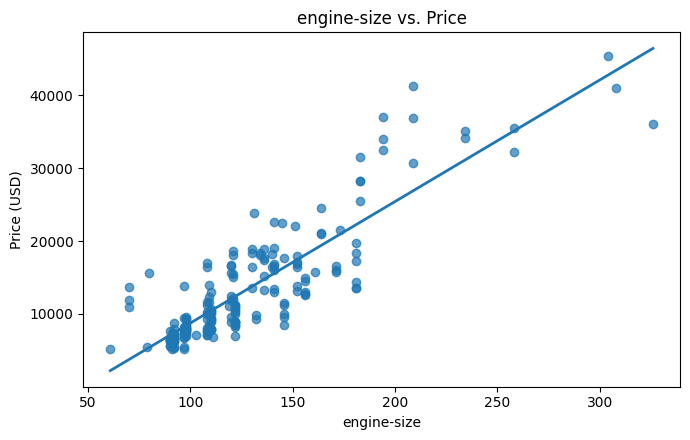

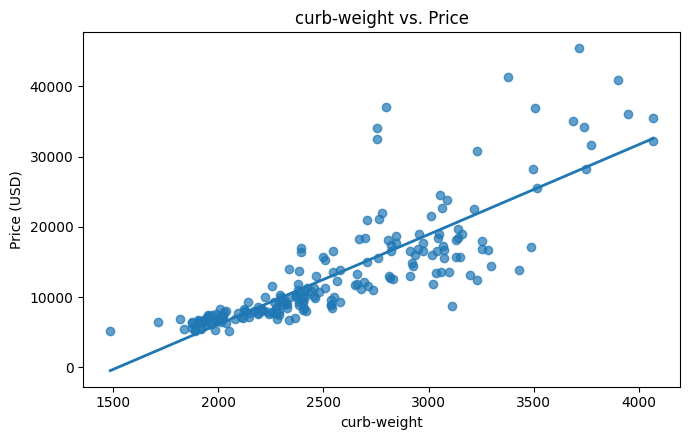

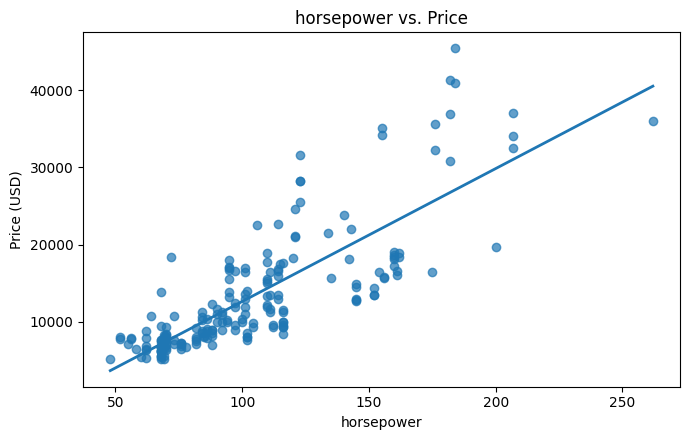

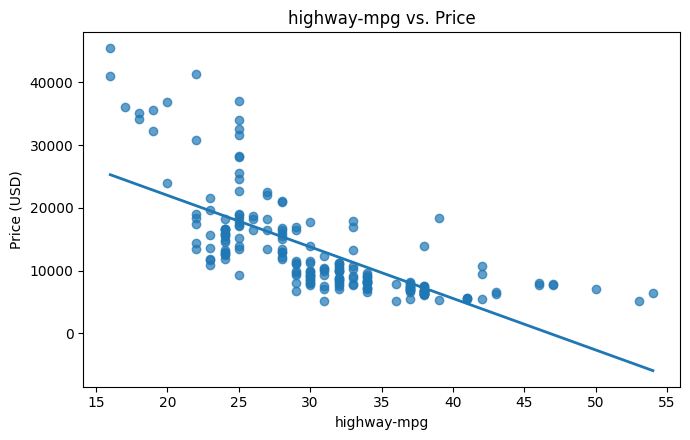

In [8]:
selected_scatter_features = [
    "engine-size",
    "curb-weight",
    "horsepower",
    "highway-mpg",
]

for feature in selected_scatter_features:
    x = df[feature].to_numpy()
    y = df["price"].to_numpy()

    slope, intercept = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = intercept + slope * x_line

    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.scatter(x, y, alpha=0.7)
    ax.plot(x_line, y_line, linewidth=2)
    ax.set_title(f"{feature} vs. Price")
    ax.set_xlabel(feature)
    ax.set_ylabel("Price (USD)")
    plt.tight_layout()
    plt.show()

### Interpretation

The plots reinforce the correlation results:

- **Engine size** has a particularly strong positive relationship with price.
- **Curb weight** and **horsepower** also rise substantially with price.
- **Highway MPG** has a clear negative association with price.

The scatter around the fitted lines also shows why correlation alone is insufficient: observations do not fall perfectly on a line, and some high-price vehicles depart considerably from the dominant pattern. These residual differences become important in the regression notebooks.


## 4. Question 3 — How does price vary across categorical characteristics?

We will use boxplots, frequency tables, grouping, and pivot tables. The focus is on whether category differences are both visible and supported by adequate sample sizes.

We begin with `drive-wheels`, `body-style`, and `engine-location`.


In [9]:
def categorical_price_summary(data, column):
    return (
        data.groupby(column, observed=False)["price"]
            .agg(["count", "mean", "median", "std"])
            .sort_values("mean", ascending=False)
    )

drive_wheels_summary = categorical_price_summary(df, "drive-wheels")
drive_wheels_summary

,count,mean,median,std
drive-wheels,,,,
rwd,75,"19,757.613","16,900.000","9,082.576"
4wd,8,"10,241.000","9,005.500","3,288.211"
fwd,118,"9,244.780","8,192.000","3,345.898"


In [10]:
body_style_summary = categorical_price_summary(df, "body-style")
body_style_summary

,count,mean,median,std
body-style,,,,
hardtop,8,"22,208.500","19,687.500","14,555.521"
convertible,6,"21,890.500","17,084.500","11,187.802"
sedan,94,"14,459.755","11,078.500","8,523.210"
wagon,25,"12,371.960","11,694.000","5,120.949"
hatchback,68,"9,957.441","8,672.000","4,148.864"


In [11]:
engine_location_summary = categorical_price_summary(df, "engine-location")
engine_location_summary

,count,mean,median,std
engine-location,,,,
rear,3,"34,528.000","34,028.000","2,291.288"
front,198,"12,884.086","10,221.500","7,552.279"


### Distribution-aware categorical comparisons

Boxplots are useful because they show medians, spread, and potential extreme observations rather than only group means. They also make small or imbalanced groups easier to recognize.


/tmp/ipykernel_862/2954948580.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=order)


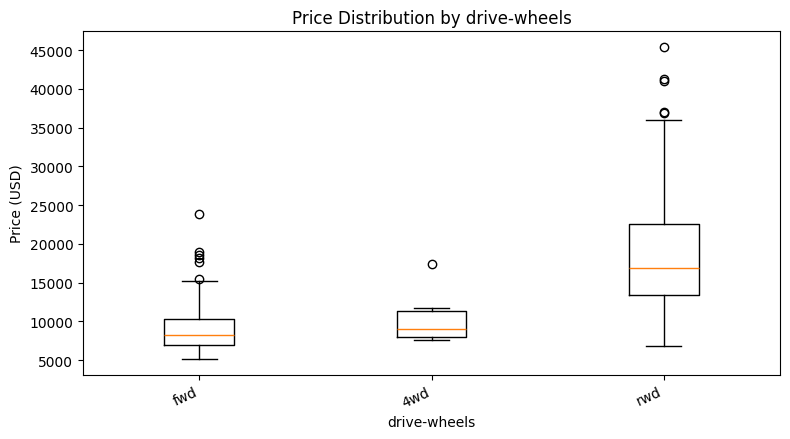

In [12]:
def grouped_boxplot(data, category, order=None, figsize=(8, 4.5)):
    if order is None:
        order = list(data.groupby(category, observed=False)["price"].median().sort_values().index)

    groups = [data.loc[data[category] == level, "price"].to_numpy() for level in order]

    fig, ax = plt.subplots(figsize=figsize)
    ax.boxplot(groups, labels=order)
    ax.set_title(f"Price Distribution by {category}")
    ax.set_xlabel(category)
    ax.set_ylabel("Price (USD)")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.show()

grouped_boxplot(df, "drive-wheels")

/tmp/ipykernel_862/2954948580.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=order)


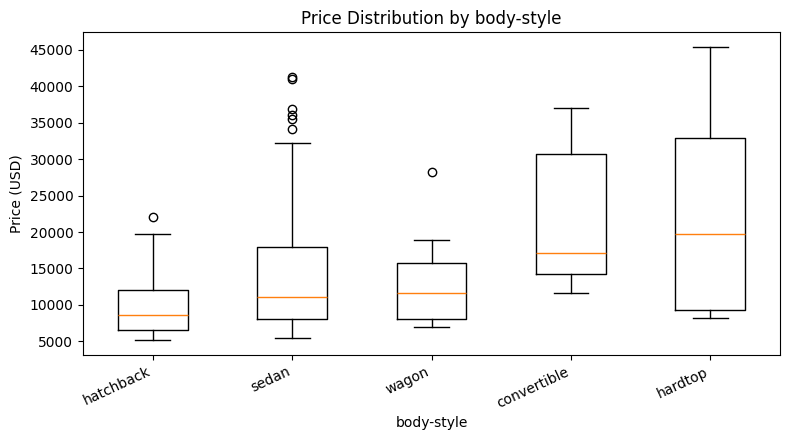

In [13]:
grouped_boxplot(df, "body-style")

/tmp/ipykernel_862/2954948580.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=order)


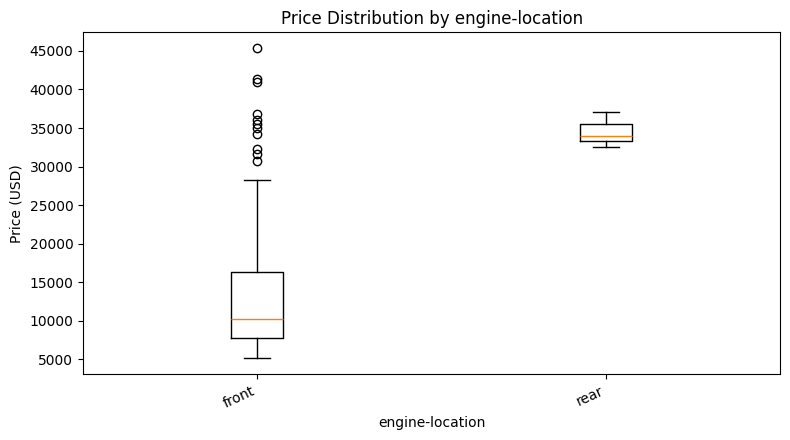

In [14]:
grouped_boxplot(df, "engine-location")

### Interpretation and sample-size caution

`drive-wheels` shows meaningful price separation and has enough observations across its main categories to be useful in later analysis.

`body-style` also shows price differences, although the distributions overlap substantially; this suggests that body style alone is unlikely to explain price well.

`engine-location` appears strongly differentiated, but this comparison must be treated cautiously because rear-engine automobiles are very rare in the dataset. A striking difference based on only a few observations should not be interpreted as a stable population relationship.


## 5. Drive wheels and body style together

We then use grouping and a pivot table to examine the joint relationship of drivetrain and body style with average price. It illustrates how categorical characteristics can interact descriptively.

Blank combinations are left as missing rather than replaced with zero: an unobserved category combination does **not** represent a zero-dollar automobile.


In [15]:
drive_body_price = (
    df.groupby(["drive-wheels", "body-style"], observed=False)["price"]
      .mean()
      .unstack()
)

drive_body_price

body-style,convertible,hardtop,hatchback,sedan,wagon
drive-wheels,,,,,
4wd,NaN,NaN,"7,603.000","12,647.333","9,095.750"
fwd,"11,595.000","8,249.000","8,396.388","9,811.800","9,997.333"
rwd,"23,949.600","24,202.714","14,337.778","21,711.833","16,994.222"


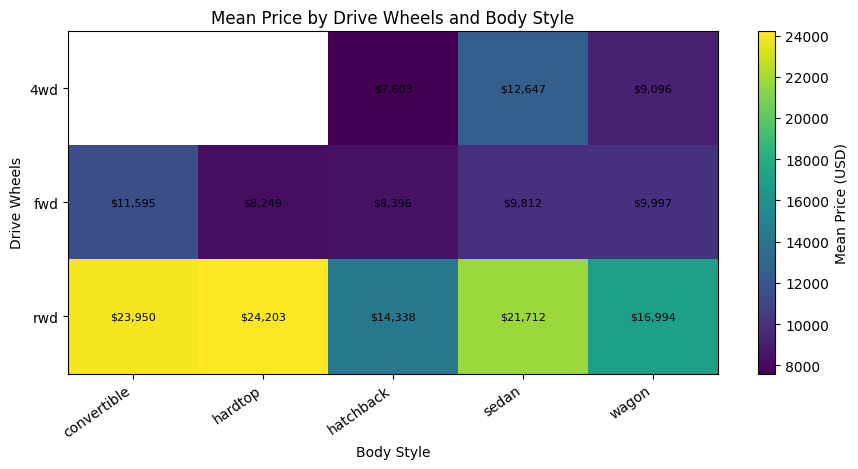

In [16]:
fig, ax = plt.subplots(figsize=(9, 4.8))

matrix = np.ma.masked_invalid(drive_body_price.to_numpy())
image = ax.imshow(matrix, aspect="auto")

ax.set_xticks(np.arange(len(drive_body_price.columns)))
ax.set_xticklabels(drive_body_price.columns, rotation=35, ha="right")
ax.set_yticks(np.arange(len(drive_body_price.index)))
ax.set_yticklabels(drive_body_price.index)

ax.set_title("Mean Price by Drive Wheels and Body Style")
ax.set_xlabel("Body Style")
ax.set_ylabel("Drive Wheels")

for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        value = drive_body_price.iloc[i, j]
        if pd.notna(value):
            ax.text(j, i, f"${value:,.0f}", ha="center", va="center", fontsize=8)

fig.colorbar(image, ax=ax, label="Mean Price (USD)")
plt.tight_layout()
plt.show()

## 6. Question 4 — Are the strongest candidate predictors also related to one another?

A variable can have a strong bivariate relationship with price while sharing much of the same information as other predictors. This matters when moving from simple to multiple regression.

For example, larger engines often accompany greater horsepower and heavier vehicles, while city and highway MPG measure closely related aspects of fuel economy.

The matrix below focuses on the leading candidate predictors from the EDA.


In [17]:
candidate_model_features = [
    "engine-size",
    "curb-weight",
    "horsepower",
    "width",
    "length",
    "wheel-base",
    "city-mpg",
    "highway-mpg",
    "bore",
    "price",
]

corr_matrix = df[candidate_model_features].corr()
corr_matrix.round(3)

,engine-size,curb-weight,horsepower,width,length,wheel-base,city-mpg,highway-mpg,bore,price
engine-size,1.000,0.849,0.823,0.729,0.685,0.572,-0.651,-0.680,0.573,0.872
curb-weight,0.849,1.000,0.758,0.866,0.881,0.782,-0.750,-0.795,0.644,0.834
horsepower,0.823,0.758,1.000,0.615,0.580,0.371,-0.822,-0.805,0.567,0.810
width,0.729,0.866,0.615,1.000,0.857,0.815,-0.634,-0.681,0.545,0.751
length,0.685,0.881,0.580,0.857,1.000,0.876,-0.665,-0.698,0.609,0.691
wheel-base,0.572,0.782,0.371,0.815,0.876,1.000,-0.471,-0.543,0.493,0.585
city-mpg,-0.651,-0.750,-0.822,-0.634,-0.665,-0.471,1.000,0.972,-0.582,-0.687
highway-mpg,-0.680,-0.795,-0.805,-0.681,-0.698,-0.543,0.972,1.000,-0.591,-0.705
bore,0.573,0.644,0.567,0.545,0.609,0.493,-0.582,-0.591,1.000,0.543
price,0.872,0.834,0.810,0.751,0.691,0.585,-0.687,-0.705,0.543,1.000


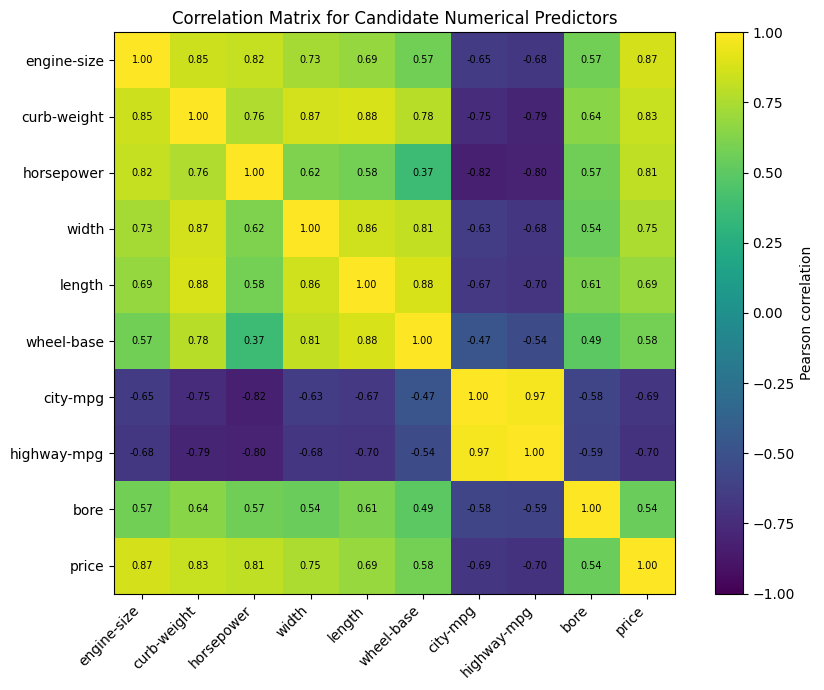

In [18]:
fig, ax = plt.subplots(figsize=(9, 7))
image = ax.imshow(corr_matrix.to_numpy(), vmin=-1, vmax=1)

ax.set_xticks(np.arange(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha="right")
ax.set_yticks(np.arange(len(corr_matrix.index)))
ax.set_yticklabels(corr_matrix.index)

for i in range(len(corr_matrix.index)):
    for j in range(len(corr_matrix.columns)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}",
                ha="center", va="center", fontsize=7)

ax.set_title("Correlation Matrix for Candidate Numerical Predictors")
fig.colorbar(image, ax=ax, label="Pearson correlation")
plt.tight_layout()
plt.show()

In [19]:
feature_only_corr = df[candidate_model_features[:-1]].corr().abs()

upper_triangle = feature_only_corr.where(
    np.triu(np.ones(feature_only_corr.shape), k=1).astype(bool)
)

high_overlap = (
    upper_triangle.stack()
                  .reset_index()
                  .rename(columns={
                      "level_0": "feature_1",
                      "level_1": "feature_2",
                      0: "absolute_correlation",
                  })
                  .sort_values("absolute_correlation", ascending=False)
)

high_overlap.head(10)

,feature_1,feature_2,absolute_correlation
33,city-mpg,highway-mpg,0.972
10,curb-weight,length,0.881
26,length,wheel-base,0.876
9,curb-weight,width,0.866
21,width,length,0.857
0,engine-size,curb-weight,0.849
1,engine-size,horsepower,0.823
18,horsepower,city-mpg,0.822
22,width,wheel-base,0.815
19,horsepower,highway-mpg,0.805


### Multicollinearity implication

Several candidate predictors are strongly correlated with one another. In particular, pairs related to physical size, power, and fuel economy can contain overlapping information.

This does **not** mean those variables are unusable. It means their coefficients in a multiple regression should be interpreted more carefully than their individual correlations with price.

This observation provides an important bridge to Notebook 04:

- **Simple linear regression** can quantify individual price relationships.
- **Multiple linear regression** can assess their combined explanatory value.
- Comparing the two helps determine whether several highly correlated predictors genuinely add information beyond one another.


## 7. Question 5 — Which variables should move forward to regression modeling?

To make the transition from EDA to modeling explicit, the main findings are summarized below.

### Strong candidates
The strongest continuous associations with price are concentrated among:

- `engine-size`
- `curb-weight`
- `horsepower`
- `width`
- `length`
- `wheel-base`
- `city-mpg`
- `highway-mpg`
- `bore`

Among the categorical variables examined, `drive-wheels` shows useful descriptive price separation and adequate representation across categories.

### Variables requiring caution
- `engine-location` shows large price differences but has a very small rear-engine group.
- Some continuous predictors contain substantial overlapping information.
- `city-mpg` and `highway-mpg` are particularly similar measures and should not automatically be included together.
- Strong bivariate association should not be interpreted as an independent or causal effect.

The regression stage should therefore compare parsimonious specifications rather than include every correlated variable simply because it has a low p-value.


In [20]:
eda_summary = price_correlations[
    price_correlations["feature"].isin([
        "engine-size", "curb-weight", "horsepower", "width",
        "length", "wheel-base", "city-mpg", "highway-mpg", "bore"
    ])
].copy()

eda_summary["direction"] = np.where(
    eda_summary["pearson_r"] >= 0, "Positive", "Negative"
)
eda_summary["statistically_significant_0.05"] = eda_summary["p_value"] < 0.05

eda_summary[
    ["feature", "pearson_r", "p_value", "direction", "statistically_significant_0.05"]
]

,feature,pearson_r,p_value,direction,statistically_significant_0.05
0,engine-size,0.872,0.000,Positive,True
1,curb-weight,0.834,0.000,Positive,True
2,horsepower,0.810,0.000,Positive,True
3,width,0.751,0.000,Positive,True
4,highway-mpg,-0.705,0.000,Negative,True
5,length,0.691,0.000,Positive,True
6,city-mpg,-0.687,0.000,Negative,True
7,wheel-base,0.585,0.000,Positive,True
8,bore,0.543,0.000,Positive,True


## 8. EDA conclusions

The exploratory analysis supports five main conclusions:

1. **Automobile price is right-skewed**, with a comparatively small number of high-price vehicles.
2. **Engine size, curb weight, horsepower, and vehicle width** have some of the strongest positive linear relationships with price.
3. **City and highway MPG** are negatively associated with price in this historical sample.
4. **Drive-wheel configuration** is a potentially informative categorical characteristic, whereas very small groups such as rear-engine vehicles require cautious interpretation.
5. Several strong predictors are also **strongly correlated with one another**, so individual Pearson correlations should not be treated as independent contributions to price.

These findings justify the next stage of the project without predetermining its result.

### Handoff to Notebook 04 — Regression Model Development

Notebook 04 will use the EDA evidence to develop and compare:

- **Simple Linear Regression (SLR)** for selected individual relationships;
- **Multiple Linear Regression (MLR)** for combined predictors;
- **Polynomial Regression** where the data suggest that a linear specification may be too restrictive.

The purpose will be to translate exploratory relationships into explicit regression specifications and evaluate how well those specifications explain automobile price.
